In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
%pip install numpy pandas matplotlib scikit-learn pillow tqdm kagglehub

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/10.0 MB 15.1 MB/s eta 0:00:01
   ----------------- ---------------------- 4.5/10.0 MB 11.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/10.0 MB 10.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/10.0 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 10.0 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------- ------------------------------ 2.1/9.3 MB 9.0 MB/s eta 0:00:01
   ------------ --------------------------- 2.9/9.3 MB 7.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.3 MB 6.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 7.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.5 MB/s  0:00:01
   -----------------

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CIFAKE

In [4]:
c

print("Dataset downloaded to:")
print(path)

100%|██████████| 105M/105M [00:06<00:00, 18.1MB/s] 

Extracting files...


Dataset downloaded to:
C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [5]:
import os

print(os.listdir(path))

['test', 'train']


In [6]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for file in files[:3]:
            print(indent + "    " + file)

3/
    test/
        FAKE/
        REAL/
    train/
        FAKE/
        REAL/


In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

print(path)

C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [8]:
import os
print(os.listdir(path))

['test', 'train']


In [9]:
from pathlib import Path

train_dir = Path(path) / "train"
test_dir = Path(path) / "test"

print("Training REAL:", len(list((train_dir / "REAL").glob("*"))))
print("Training FAKE:", len(list((train_dir / "FAKE").glob("*"))))

print("Testing REAL:", len(list((test_dir / "REAL").glob("*"))))
print("Testing FAKE:", len(list((test_dir / "FAKE").glob("*"))))

Training REAL: 50000
Training FAKE: 50000
Testing REAL: 10000
Testing FAKE: 10000


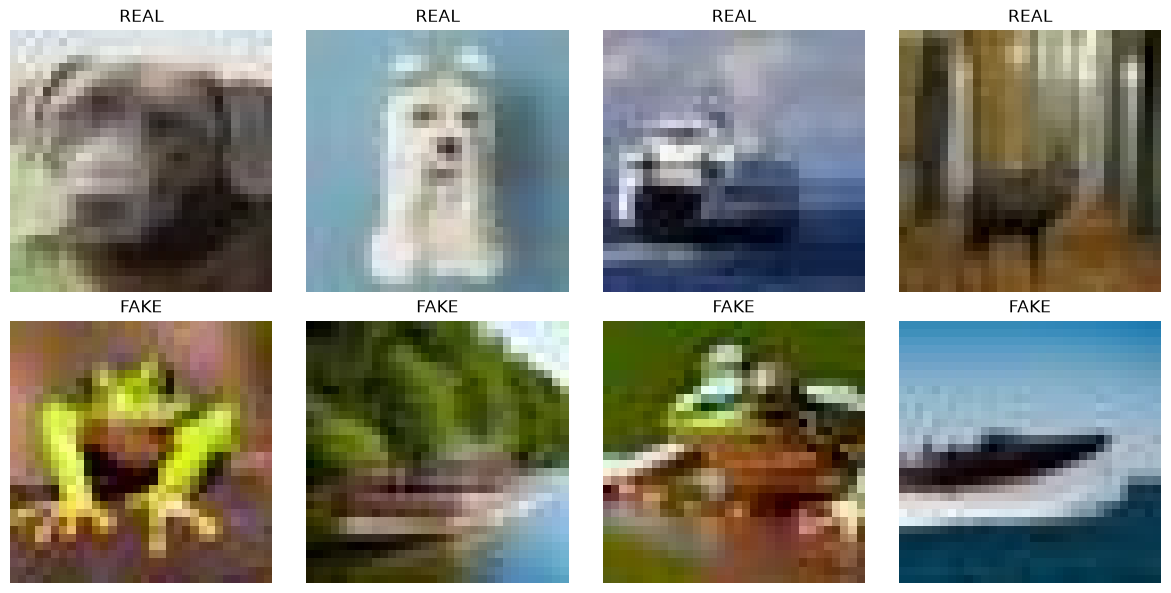

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import random

classes = ["REAL", "FAKE"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, class_name in enumerate(classes):
    image_files = list((train_dir / class_name).glob("*"))
    selected = random.sample(image_files, 4)

    for col, image_file in enumerate(selected):
        img = Image.open(image_file)

        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [11]:
#feed into one group of 64 images

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# How we prepare every image before giving it to ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load the folders
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Class numbers:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['FAKE', 'REAL']
Class numbers: {'FAKE': 0, 'REAL': 1}
Training images: 100000
Testing images: 20000


In [13]:
#create batches

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 1563
Testing batches: 313


In [16]:
#final check

In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
First 10 labels: tensor([0, 1, 1, 0, 1, 1, 0, 0, 1, 0])


In [17]:
#Load ResNet18

In [18]:
import torch.nn as nn
from torchvision import models

# Load a pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Change the final layer to output 2 classes:
# 0 = FAKE
# 1 = REAL
model.fc = nn.Linear(model.fc.in_features, 2)

# Move the model onto your RTX 4050
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\kaise/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Linear(in_features=512, out_features=2, bias=True)


In [ ]:
#Make sure ResNet18 actually runs

In [19]:
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Output shape:", outputs.shape)
print("First image output:", outputs[0])

Output shape: torch.Size([64, 2])
First image output: tensor([ 0.5899, -0.6673], device='cuda:0')


In [20]:
# Freeze all existing ResNet layers
for param in model.parameters():
    param.requires_grad = False

# Allow only the final classifier to learn
for param in model.fc.parameters():
    param.requires_grad = True

In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Training setup ready!")

Training setup ready!


In [22]:
#Do one training epoch

In [23]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for batch_number, (images, labels) in enumerate(train_loader):

    # Move data to RTX 4050
    images = images.to(device)
    labels = labels.to(device)

    # Clear old gradients
    optimizer.zero_grad()

    # Make predictions
    outputs = model(images)

    # Calculate how wrong the predictions are
    loss = criterion(outputs, labels)

    # Learn from the mistake
    loss.backward()
    optimizer.step()

    # Record statistics
    running_loss += loss.item()

    predictions = outputs.argmax(dim=1)

    total += labels.size(0)
    correct += (predictions == labels).sum().item()

    # Show progress every 200 batches
    if (batch_number + 1) % 200 == 0:
        print(
            f"Batch {batch_number + 1}/{len(train_loader)} | "
            f"Loss: {running_loss / (batch_number + 1):.4f} | "
            f"Accuracy: {100 * correct / total:.2f}%"
        )

print()
print("Training finished!")
print(f"Training Accuracy: {100 * correct / total:.2f}%")

Batch 200/1563 | Loss: 0.4443 | Accuracy: 79.09%
Batch 400/1563 | Loss: 0.3979 | Accuracy: 81.93%
Batch 600/1563 | Loss: 0.3739 | Accuracy: 83.28%
Batch 800/1563 | Loss: 0.3613 | Accuracy: 84.04%
Batch 1000/1563 | Loss: 0.3522 | Accuracy: 84.52%
Batch 1200/1563 | Loss: 0.3459 | Accuracy: 84.86%
Batch 1400/1563 | Loss: 0.3417 | Accuracy: 85.07%

Training finished!
Training Accuracy: 85.23%


In [24]:
#Test Data

In [25]:
from sklearn.metrics import roc_auc_score
import torch

model.eval()

correct = 0
total = 0

all_ai_probs = []
all_true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Model predictions
        outputs = model(images)

        # Convert scores into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Remember:
        # 0 = FAKE
        # 1 = REAL
        ai_probs = probabilities[:, 0]

        # Choose the class with the highest probability
        predictions = outputs.argmax(dim=1)

        # Accuracy
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        # Store AI probabilities for AUC
        all_ai_probs.extend(ai_probs.cpu().numpy())

        # Convert labels:
        # FAKE = 1 (AI)
        # REAL = 0
        true_ai = (labels == 0).int()

        all_true_labels.extend(true_ai.cpu().numpy())


test_accuracy = 100 * correct / total
test_auc = roc_auc_score(all_true_labels, all_ai_probs)

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

Test Accuracy: 88.19%
Test AUC: 0.9517


In [26]:
#save baseline v0

In [27]:
torch.save(model.state_dict(), "resnet18_cifake_baseline_v0.pth")

print("Baseline V0 saved!")

Baseline V0 saved!


In [32]:
from sklearn.metrics import roc_auc_score
import torch

def evaluate_model(model, loader):
    
    model.eval()

    correct = 0
    total = 0

    all_ai_probs = []
    all_true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            # 0 = FAKE, so column 0 is AI probability
            ai_probs = probabilities[:, 0]

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

            all_ai_probs.extend(ai_probs.cpu().numpy())

            # Convert:
            # FAKE → 1
            # REAL → 0
            true_ai = (labels == 0).int()

            all_true_labels.extend(true_ai.cpu().numpy())

    accuracy = 100 * correct / total
    auc = roc_auc_score(all_true_labels, all_ai_probs)

    return accuracy, auc

In [33]:
import io
from PIL import Image

def jpeg_compress(img, quality=30):
    
    buffer = io.BytesIO()

    img.save(
        buffer,
        format="JPEG",
        quality=quality
    )

    buffer.seek(0)

    compressed_img = Image.open(buffer).convert("RGB")

    return compressed_img

In [34]:
jpeg30_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: jpeg_compress(img, quality=30)
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
jpeg30_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=jpeg30_transform
)

jpeg30_loader = DataLoader(
    jpeg30_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("JPEG test loader ready!")
print("Number of batches:", len(jpeg30_loader))

JPEG test loader ready!
Number of batches: 313


In [36]:
jpeg30_accuracy, jpeg30_auc = evaluate_model(
    model,
    jpeg30_loader
)

print(f"Clean Accuracy: 88.19%")
print(f"Clean AUC:      0.9517")

print()

print(f"JPEG 30 Accuracy: {jpeg30_accuracy:.2f}%")
print(f"JPEG 30 AUC:      {jpeg30_auc:.4f}")

Clean Accuracy: 88.19%
Clean AUC:      0.9517

JPEG 30 Accuracy: 83.44%
JPEG 30 AUC:      0.9176


In [37]:
#Gaussian Blur

In [38]:
blur_transform = transforms.Compose([
    transforms.GaussianBlur(
        kernel_size=9,
        sigma=2.0
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
blur_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=blur_transform
)

blur_loader = DataLoader(
    blur_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [41]:
blur_accuracy, blur_auc = evaluate_model(
    model,
    blur_loader
)

print(f"Clean Accuracy:   88.19%")
print(f"Clean AUC:        0.9517")

print()

print(f"JPEG 30 Accuracy: {jpeg30_accuracy:.2f}%")
print(f"JPEG 30 AUC:      {jpeg30_auc:.4f}")

print()

print(f"Blur Accuracy:    {blur_accuracy:.2f}%")
print(f"Blur AUC:         {blur_auc:.4f}")

Clean Accuracy:   88.19%
Clean AUC:        0.9517

JPEG 30 Accuracy: 83.44%
JPEG 30 AUC:      0.9176

Blur Accuracy:    53.09%
Blur AUC:         0.6561


In [43]:
resize_transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [44]:
resize_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=resize_transform
)

resize_loader = DataLoader(
    resize_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [45]:
resize_accuracy, resize_auc = evaluate_model(
    model,
    resize_loader
)

print(f"Resize Accuracy: {resize_accuracy:.2f}%")
print(f"Resize AUC:      {resize_auc:.4f}")

Resize Accuracy: 56.38%
Resize AUC:      0.6779


Our baseline detector depends strongly on high-frequency information, so transformations that remove fine detail—especially blur and aggressive resizing—will cause the largest degradation

In [47]:
crop_transform = transforms.Compose([
    transforms.CenterCrop(26),   # about 80% of 32 pixels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [48]:
crop_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=crop_transform
)

crop_loader = DataLoader(
    crop_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [49]:
crop_accuracy, crop_auc = evaluate_model(
    model,
    crop_loader
)

print(f"Crop Accuracy: {crop_accuracy:.2f}%")
print(f"Crop AUC:      {crop_auc:.4f}")

Crop Accuracy: 81.39%
Crop AUC:      0.9270


The baseline is relatively robust to cropping and JPEG compression, but highly vulnerable to transformations that destroy fine image detail.

In [50]:
def add_gaussian_noise(tensor, sigma=0.10):
    noise = torch.randn_like(tensor) * sigma
    noisy = tensor + noise

    return torch.clamp(noisy, 0, 1)

In [51]:
noise_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Lambda(
        lambda x: add_gaussian_noise(x, sigma=0.10)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
noise_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=noise_transform
)

noise_loader = DataLoader(
    noise_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [53]:
noise_accuracy, noise_auc = evaluate_model(
    model,
    noise_loader
)

print(f"Noise Accuracy: {noise_accuracy:.2f}%")
print(f"Noise AUC:      {noise_auc:.4f}")

Noise Accuracy: 50.18%
Noise AUC:      0.5415


In [54]:
color_transform = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [55]:
color_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=color_transform
)

color_loader = DataLoader(
    color_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

color_accuracy, color_auc = evaluate_model(
    model,
    color_loader
)

print(f"Color Jitter Accuracy: {color_accuracy:.2f}%")
print(f"Color Jitter AUC:      {color_auc:.4f}")

Color Jitter Accuracy: 86.75%
Color Jitter AUC:      0.9402


In [56]:
#Build Robust Model V1

In [57]:
import random
import io
import torch
from torchvision import transforms


class RobustTrainTransform:

    def __init__(self):

        self.resize_final = transforms.Resize((224, 224))

        self.to_tensor = transforms.ToTensor()

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __call__(self, img):

        img = img.convert("RGB")

        # Two "clean" choices help us preserve clean-image accuracy
        augmentation = random.choice([
            "clean",
            "clean",
            "jpeg",
            "blur",
            "resize",
            "noise",
            "color",
            "crop"
        ])


        # JPEG COMPRESSION
        if augmentation == "jpeg":

            quality = random.choice([30, 50, 70, 90])

            buffer = io.BytesIO()

            img.save(
                buffer,
                format="JPEG",
                quality=quality
            )

            buffer.seek(0)

            from PIL import Image
            img = Image.open(buffer).convert("RGB")


        # GAUSSIAN BLUR
        elif augmentation == "blur":

            sigma = random.choice([
                0.5,
                1.0,
                2.0
            ])

            img = transforms.GaussianBlur(
                kernel_size=9,
                sigma=sigma
            )(img)


        # RESIZE DOWN → UPSCALE
        elif augmentation == "resize":

            scale = random.choice([
                0.5,
                0.25
            ])

            width, height = img.size

            small_width = max(1, int(width * scale))
            small_height = max(1, int(height * scale))

            img = img.resize(
                (small_width, small_height)
            )

            img = img.resize(
                (width, height)
            )


        # COLOR JITTER
        elif augmentation == "color":

            img = transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2
            )(img)


        # CENTER CROP 80%
        elif augmentation == "crop":

            width, height = img.size

            crop_size = int(
                min(width, height) * 0.8
            )

            img = transforms.CenterCrop(
                crop_size
            )(img)


        # Convert everything to 224 × 224
        img = self.resize_final(img)

        img = self.to_tensor(img)


        # GAUSSIAN NOISE
        if augmentation == "noise":

            sigma = random.choice([
                0.02,
                0.05,
                0.10
            ])

            noise = torch.randn_like(img) * sigma

            img = torch.clamp(
                img + noise,
                0,
                1
            )


        img = self.normalize(img)

        return img

In [58]:
robust_transform = RobustTrainTransform()

robust_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=robust_transform
)

robust_train_loader = DataLoader(
    robust_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

print("Robust training dataset ready!")
print("Images:", len(robust_train_dataset))
print("Batches:", len(robust_train_loader))

Robust training dataset ready!
Images: 100000
Batches: 1563


In [59]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False


# Unfreeze the last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True


# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True


trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable)

Trainable parameters: 8394754


In [60]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

print("Robust training ready!")

Robust training ready!


In [61]:
epochs = 2

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_number, (images, labels) in enumerate(robust_train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


        if (batch_number + 1) % 200 == 0:

            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Batch {batch_number + 1}/{len(robust_train_loader)} | "
                f"Loss: {running_loss/(batch_number+1):.4f} | "
                f"Accuracy: {100*correct/total:.2f}%"
            )


    print()
    print(
        f"Epoch {epoch + 1} complete | "
        f"Accuracy: {100*correct/total:.2f}%"
    )

Epoch 1/2 | Batch 200/1563 | Loss: 0.3238 | Accuracy: 86.43%
Epoch 1/2 | Batch 400/1563 | Loss: 0.2899 | Accuracy: 87.75%
Epoch 1/2 | Batch 600/1563 | Loss: 0.2728 | Accuracy: 88.45%
Epoch 1/2 | Batch 800/1563 | Loss: 0.2580 | Accuracy: 89.17%
Epoch 1/2 | Batch 1000/1563 | Loss: 0.2466 | Accuracy: 89.68%
Epoch 1/2 | Batch 1200/1563 | Loss: 0.2406 | Accuracy: 89.98%
Epoch 1/2 | Batch 1400/1563 | Loss: 0.2324 | Accuracy: 90.35%

Epoch 1 complete | Accuracy: 90.62%
Epoch 2/2 | Batch 200/1563 | Loss: 0.1740 | Accuracy: 92.91%
Epoch 2/2 | Batch 400/1563 | Loss: 0.1655 | Accuracy: 93.29%
Epoch 2/2 | Batch 600/1563 | Loss: 0.1634 | Accuracy: 93.37%
Epoch 2/2 | Batch 800/1563 | Loss: 0.1623 | Accuracy: 93.43%
Epoch 2/2 | Batch 1000/1563 | Loss: 0.1603 | Accuracy: 93.57%
Epoch 2/2 | Batch 1200/1563 | Loss: 0.1580 | Accuracy: 93.67%
Epoch 2/2 | Batch 1400/1563 | Loss: 0.1568 | Accuracy: 93.71%

Epoch 2 complete | Accuracy: 93.78%


In [62]:
clean_accuracy_v1, clean_auc_v1 = evaluate_model(
    model,
    test_loader
)

jpeg_accuracy_v1, jpeg_auc_v1 = evaluate_model(
    model,
    jpeg30_loader
)

blur_accuracy_v1, blur_auc_v1 = evaluate_model(
    model,
    blur_loader
)

resize_accuracy_v1, resize_auc_v1 = evaluate_model(
    model,
    resize_loader
)

noise_accuracy_v1, noise_auc_v1 = evaluate_model(
    model,
    noise_loader
)

crop_accuracy_v1, crop_auc_v1 = evaluate_model(
    model,
    crop_loader
)

color_accuracy_v1, color_auc_v1 = evaluate_model(
    model,
    color_loader
)

In [63]:
print("ROBUST MODEL V1")
print("----------------------------")

print(f"Clean:       {clean_accuracy_v1:.2f}%")
print(f"JPEG 30:     {jpeg_accuracy_v1:.2f}%")
print(f"Blur:        {blur_accuracy_v1:.2f}%")
print(f"Resize:      {resize_accuracy_v1:.2f}%")
print(f"Noise:       {noise_accuracy_v1:.2f}%")
print(f"Crop:        {crop_accuracy_v1:.2f}%")
print(f"Color:       {color_accuracy_v1:.2f}%")

ROBUST MODEL V1
----------------------------
Clean:       96.64%
JPEG 30:     93.50%
Blur:        88.36%
Resize:      76.19%
Noise:       92.50%
Crop:        94.67%
Color:       95.88%


In [67]:
torch.save(
    model.state_dict(),
    "robust_model_v1.pth"
)

print("Robust Model V1 saved.")

Robust Model V1 saved.


In [68]:
from torchvision import models
import torch.nn as nn
import torch

test_model = models.resnet18(weights=None)

test_model.fc = nn.Linear(
    test_model.fc.in_features,
    2
)

test_model.load_state_dict(
    torch.load(
        "robust_model_v1.pth",
        map_location=device
    )
)

test_model = test_model.to(device)
test_model.eval()

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


In [69]:
v1_config = {
    "model": "ResNet18",
    "pretrained": True,

    "trainable_layers": [
        "layer4",
        "fc"
    ],

    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "epochs": 2,

    "training_augmentations": [
        "clean",
        "JPEG",
        "Gaussian Blur",
        "Resize",
        "Gaussian Noise",
        "Color Jitter",
        "Center Crop"
    ],

    "results": {
        "clean": 96.64,
        "jpeg30": 93.50,
        "blur_sigma2": 88.36,
        "resize_0.25": 76.19,
        "noise_0.10": 92.50,
        "crop80": 94.67,
        "color": 95.88
    }
}

In [70]:
import json

with open(
    "robust_model_v1_config.json",
    "w"
) as f:
    json.dump(
        v1_config,
        f,
        indent=4
    )

In [71]:
import os
import shutil

# Create models folder
os.makedirs("models", exist_ok=True)

# Check what .pth files currently exist
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

.\resnet18_cifake_baseline_v0.pth
.\robust_model_v1.pth
.\.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
.\AppData\Local\FortniteGame\Intermediate\PipInstall\Lib\site-packages\learning_agents.pth
.\IE2108 Tutorial 1\.venv\Lib\site-packages\_virtualenv.pth
.\miniconda3\envs\ie0005\Lib\site-packages\distutils-precedence.pth
.\miniconda3\envs\ie0005\Lib\site-packages\pywin32.pth
.\miniconda3\envs\techjam\Lib\site-packages\distutils-precedence.pth
.\miniconda3\Lib\site-packages\distutils-precedence.pth
.\miniconda3\pkgs\pywin32-311-py313h885b0b7_0\Lib\site-packages\pywin32.pth
.\miniconda3\pkgs\setuptools-80.9.0-py313haa95532_0\Lib\site-packages\distutils-precedence.pth
.\miniconda3\pkgs\setuptools-83.0.0-py311haa95532_0\Lib\site-packages\distutils-precedence.pth


In [73]:
import shutil
import os

# Move baseline into models/
if os.path.exists("resnet18_cifake_baseline_v0.pth"):
    shutil.move(
        "resnet18_cifake_baseline_v0.pth",
        "models/resnet18_cifake_baseline_v0.pth"
    )

# Move robust V1 into models/
if os.path.exists("robust_model_v1.pth"):
    shutil.move(
        "robust_model_v1.pth",
        "models/robust_model_v1.pth"
    )

print("Done!")

Done!


In [74]:
files = [
    "models/resnet18_cifake_baseline_v0.pth",
    "models/robust_model_v1.pth"
]

for file in files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"✅ {file} — {size_mb:.2f} MB")
    else:
        print(f"❌ Missing: {file}")

✅ models/resnet18_cifake_baseline_v0.pth — 42.72 MB
✅ models/robust_model_v1.pth — 42.72 MB


In [75]:
#Robust Model V1 can run well with CIFAKE and non-CIFAKE data, but not real world data

In [76]:
import os

os.makedirs("real_world_test", exist_ok=True)

print("Folder created!")

Folder created!


In [77]:
import os

files = os.listdir("real_world_test")

print("Number of files:", len(files))
print(files[:10])

Number of files: 30
['IMG-20260829-WA0001.jpg.jpeg', 'IMG_20251118_145600.jpg.jpeg', 'IMG_20251212_162737.jpg.jpeg', 'IMG_20251212_163330.jpg.jpeg', 'IMG_20251213_155148.jpg.jpeg', 'IMG_20251213_164917.jpg.jpeg', 'IMG_20251214_134833.jpg.jpeg', 'IMG_20251215_094233.jpg.jpeg', 'IMG_20260104_170358.jpg.jpeg', 'IMG_20260201_151326.jpg.jpeg']


In [78]:
#test real world pictures

In [79]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
import torch
import pandas as pd
import os

# Preprocessing used for inference
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

folder = Path("real_world_test")

image_extensions = {
    ".jpg", ".jpeg", ".png", ".webp"
}

results = []

model.eval()

for image_path in folder.iterdir():

    if image_path.suffix.lower() not in image_extensions:
        continue

    img = Image.open(image_path).convert("RGB")

    x = inference_transform(img)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(x)
        probabilities = torch.softmax(output, dim=1)[0]

    # IMPORTANT:
    # Your class mapping is:
    # 0 = FAKE / AI
    # 1 = REAL

    ai_prob = probabilities[0].item()
    real_prob = probabilities[1].item()

    prediction = "AI" if ai_prob >= 0.5 else "REAL"

    results.append({
        "image": str(image_path),
        "ai_probability": ai_prob,
        "real_probability": real_prob,
        "prediction": prediction
    })

df_real_world = pd.DataFrame(results)

display(df_real_world)

,image,ai_probability,real_probability,prediction
0,real_world_test\IMG-20260829-WA0001.jpg.jpeg,0.999534,4.655979e-04,AI
1,real_world_test\IMG_20251118_145600.jpg.jpeg,0.993002,6.998488e-03,AI
2,real_world_test\IMG_20251212_162737.jpg.jpeg,0.990050,9.949707e-03,AI
3,real_world_test\IMG_20251212_163330.jpg.jpeg,0.984485,1.551544e-02,AI
4,real_world_test\IMG_20251213_155148.jpg.jpeg,0.999764,2.363841e-04,AI
5,real_world_test\IMG_20251213_164917.jpg.jpeg,0.999968,3.174740e-05,AI
6,real_world_test\IMG_20251214_134833.jpg.jpeg,0.999710,2.902674e-04,AI
7,real_world_test\IMG_20251215_094233.jpg.jpeg,0.999865,1.354298e-04,AI
8,real_world_test\IMG_20260104_170358.jpg.jpeg,0.999991,8.646113e-06,AI
9,real_world_test\IMG_20260201_151326.jpg.jpeg,0.999941,5.864946e-05,AI


In [80]:
total = len(df_real_world)

false_ai = (
    df_real_world["prediction"] == "AI"
).sum()

correct_real = (
    df_real_world["prediction"] == "REAL"
).sum()

real_accuracy = correct_real / total * 100
false_positive_rate = false_ai / total * 100

print("REAL-WORLD TEST")
print("-------------------------")
print(f"Total real photos: {total}")
print(f"Correctly predicted REAL: {correct_real}")
print(f"Incorrectly predicted AI: {false_ai}")
print()
print(f"Real-world REAL accuracy: {real_accuracy:.2f}%")
print(f"False Positive Rate: {false_positive_rate:.2f}%")

REAL-WORLD TEST
-------------------------
Total real photos: 30
Correctly predicted REAL: 1
Incorrectly predicted AI: 29

Real-world REAL accuracy: 3.33%
False Positive Rate: 96.67%


In [81]:
os.makedirs("results", exist_ok=True)

df_real_world.to_csv(
    "results/real_world_v1.csv",
    index=False
)

print("Saved: results/real_world_v1.csv")

Saved: results/real_world_v1.csv


In [82]:
print("AI probability statistics on REAL photos")
print("----------------------------------------")

print(
    df_real_world["ai_probability"].describe()
)

print("\nThreshold check:")

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:

    predicted_ai = (
        df_real_world["ai_probability"] >= threshold
    ).sum()

    print(
        f"AI probability >= {threshold:.2f}: "
        f"{predicted_ai}/{len(df_real_world)}"
    )

AI probability statistics on REAL photos
----------------------------------------
count    30.000000
mean      0.976095
std       0.095639
min       0.475965
25%       0.992374
50%       0.999349
75%       0.999841
max       1.000000
Name: ai_probability, dtype: float64

Threshold check:
AI probability >= 0.50: 29/30
AI probability >= 0.60: 29/30
AI probability >= 0.70: 29/30
AI probability >= 0.80: 29/30
AI probability >= 0.90: 29/30
AI probability >= 0.95: 27/30


In [83]:
display(
    df_real_world[
        [
            "image",
            "ai_probability",
            "real_probability",
            "prediction"
        ]
    ].sort_values(
        "ai_probability",
        ascending=False
    )
)

,image,ai_probability,real_probability,prediction
29,real_world_test\IMG_9707.JPG.jpeg,1.000000,4.693178e-07,AI
18,real_world_test\IMG_20260617_100045.jpg.jpeg,0.999993,6.634823e-06,AI
8,real_world_test\IMG_20260104_170358.jpg.jpeg,0.999991,8.646113e-06,AI
5,real_world_test\IMG_20251213_164917.jpg.jpeg,0.999968,3.174740e-05,AI
16,real_world_test\IMG_20260603_173652.jpg.jpeg,0.999946,5.358910e-05,AI
9,real_world_test\IMG_20260201_151326.jpg.jpeg,0.999941,5.864946e-05,AI
7,real_world_test\IMG_20251215_094233.jpg.jpeg,0.999865,1.354298e-04,AI
19,real_world_test\IMG_20260618_090025.jpg.jpeg,0.999859,1.408908e-04,AI
22,real_world_test\IMG_20260726_201706.jpg.jpeg,0.999788,2.123538e-04,AI
4,real_world_test\IMG_20251213_155148.jpg.jpeg,0.999764,2.363841e-04,AI


In [84]:
#Model V2

In [1]:
!pip install -q datasets

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

In [3]:
from pathlib import Path

folders = [
    "data_v2/train/REAL",
    "data_v2/train/FAKE",
    "data_v2/val/REAL",
    "data_v2/val/FAKE"
]

for folder in folders:
    Path(folder).mkdir(
        parents=True,
        exist_ok=True
    )

print("✅ V2 folders created")

✅ V2 folders created


In [4]:
import random
import shutil
from pathlib import Path

random.seed(42)

def copy_random_images(
    source_folder,
    destination_folder,
    amount,
    prefix
):
    
    source_folder = Path(source_folder)
    destination_folder = Path(destination_folder)

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".webp"
    }

    files = [
        f for f in source_folder.iterdir()
        if f.suffix.lower() in extensions
    ]

    selected = random.sample(
        files,
        min(amount, len(files))
    )

    for i, file in enumerate(selected):

        new_name = (
            f"{prefix}_{i:05d}"
            f"{file.suffix.lower()}"
        )

        shutil.copy2(
            file,
            destination_folder / new_name
        )

    print(
        f"✅ Copied {len(selected)} "
        f"from {source_folder}"
    )

In [5]:
train_dir = Path(path) / "train"

copy_random_images(
    Path(train_dir) / "REAL",
    "data_v2/train/REAL",
    5000,
    "cifake_real"
)

copy_random_images(
    Path(train_dir) / "FAKE",
    "data_v2/train/FAKE",
    5000,
    "cifake_fake"
)

✅ Copied 5000 from C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3\train\REAL
✅ Copied 5000 from C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3\train\FAKE


In [6]:
from datasets import load_dataset

sid_train = load_dataset(
    "saberzl/SID_Set",
    split="train",
    streaming=True
)

print("✅ SID-Set streaming ready")

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

✅ SID-Set streaming ready


dict_keys(['img_id', 'image', 'mask', 'width', 'height', 'label'])
Label: 1
Image ID: full_synthetic_063970


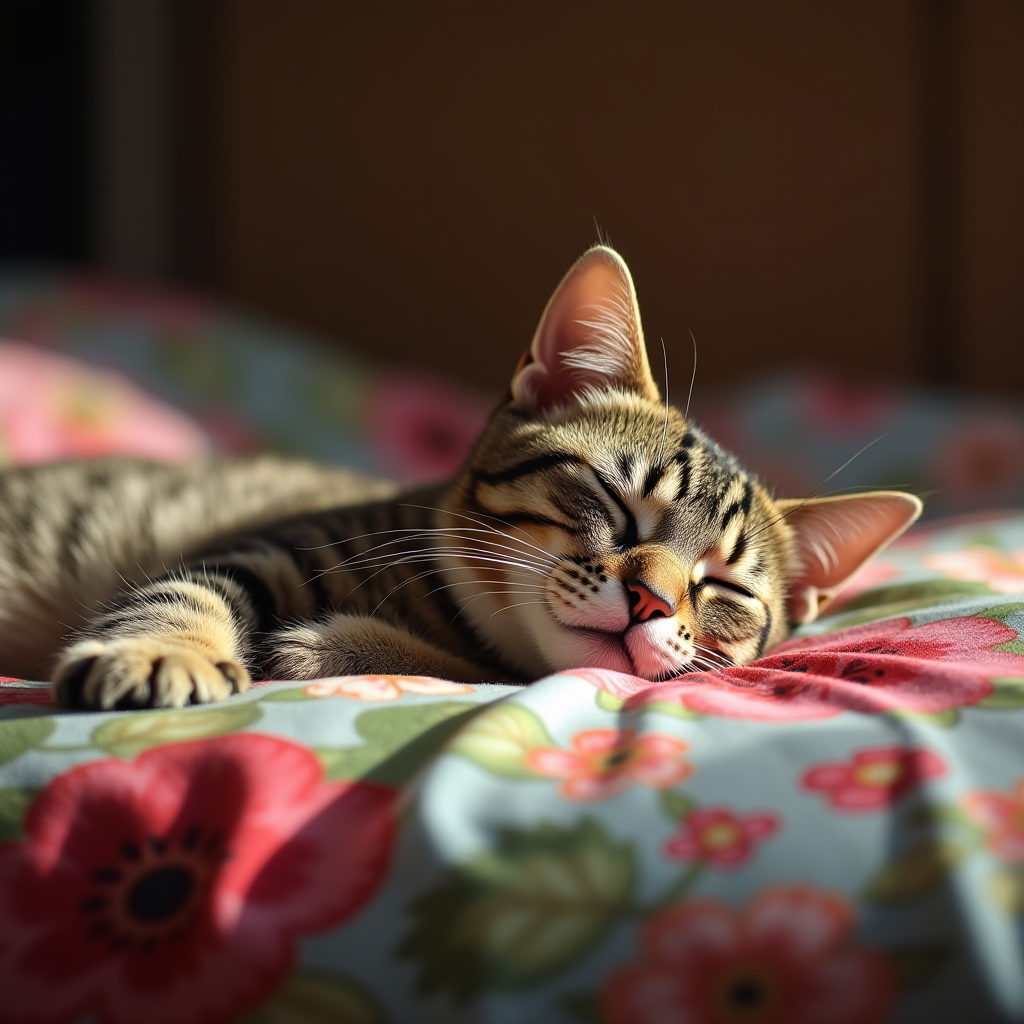

In [7]:
example = next(iter(sid_train))

print(example.keys())
print("Label:", example["label"])
print("Image ID:", example["img_id"])

display(example["image"])

In [8]:
from tqdm.auto import tqdm
from pathlib import Path

def export_sid_subset(
    split,
    real_amount,
    fake_amount,
    real_destination,
    fake_destination,
    seed=42
):

    dataset = load_dataset(
        "saberzl/SID_Set",
        split=split,
        streaming=True
    )

    dataset = dataset.shuffle(
        seed=seed,
        buffer_size=10000
    )

    real_destination = Path(
        real_destination
    )

    fake_destination = Path(
        fake_destination
    )

    real_destination.mkdir(
        parents=True,
        exist_ok=True
    )

    fake_destination.mkdir(
        parents=True,
        exist_ok=True
    )

    real_count = 0
    fake_count = 0


    progress = tqdm(
        total=real_amount + fake_amount
    )


    for row in dataset:

        label = row["label"]


        # SID label 0 = REAL
        if (
            label == 0
            and real_count < real_amount
        ):

            try:

                image = (
                    row["image"]
                    .convert("RGB")
                )

                filename = (
                    f"sid_real_"
                    f"{real_count:05d}.jpg"
                )

                image.save(
                    real_destination / filename,
                    quality=95
                )

                real_count += 1
                progress.update(1)

            except Exception as e:
                continue


        # SID label 1 = FULL SYNTHETIC
        elif (
            label == 1
            and fake_count < fake_amount
        ):

            try:

                image = (
                    row["image"]
                    .convert("RGB")
                )

                filename = (
                    f"sid_fake_"
                    f"{fake_count:05d}.jpg"
                )

                image.save(
                    fake_destination / filename,
                    quality=95
                )

                fake_count += 1
                progress.update(1)

            except Exception as e:
                continue


        # Stop once both classes are complete
        if (
            real_count >= real_amount
            and fake_count >= fake_amount
        ):
            break


    progress.close()

    print()
    print(
        f"✅ REAL saved: {real_count}"
    )

    print(
        f"✅ FAKE saved: {fake_count}"
    )

In [9]:
export_sid_subset(
    split="train",
    real_amount=5000,
    fake_amount=5000,
    real_destination="data_v2/train/REAL",
    fake_destination="data_v2/train/FAKE"
)

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
export_sid_subset(
    split="validation",
    real_amount=1000,
    fake_amount=1000,
    real_destination="data_v2/val/REAL",
    fake_destination="data_v2/val/FAKE",
    seed=123
)

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
#Testing simpler validation exporter
from datasets import load_dataset
from pathlib import Path
from tqdm.auto import tqdm


def export_sid_validation_fast(
    real_amount=1000,
    fake_amount=1000
):

    dataset = load_dataset(
        "saberzl/SID_Set",
        split="validation",
        streaming=True
    )

    real_destination = Path(
        "data_v2/val/REAL"
    )

    fake_destination = Path(
        "data_v2/val/FAKE"
    )

    real_destination.mkdir(
        parents=True,
        exist_ok=True
    )

    fake_destination.mkdir(
        parents=True,
        exist_ok=True
    )

    real_count = 0
    fake_count = 0

    progress = tqdm(
        total=real_amount + fake_amount
    )

    for row in dataset:

        label = row["label"]

        # REAL
        if label == 0 and real_count < real_amount:

            try:
                image = row["image"].convert("RGB")

                image.save(
                    real_destination /
                    f"sid_real_{real_count:05d}.jpg",
                    quality=95
                )

                real_count += 1
                progress.update(1)

            except Exception:
                continue

        # FULLY SYNTHETIC
        elif label == 1 and fake_count < fake_amount:

            try:
                image = row["image"].convert("RGB")

                image.save(
                    fake_destination /
                    f"sid_fake_{fake_count:05d}.jpg",
                    quality=95
                )

                fake_count += 1
                progress.update(1)

            except Exception:
                continue

        if (
            real_count >= real_amount
            and fake_count >= fake_amount
        ):
            break

    progress.close()

    print()
    print("✅ REAL saved:", real_count)
    print("✅ FAKE saved:", fake_count)

In [13]:
export_sid_validation_fast()

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


✅ REAL saved: 1000
✅ FAKE saved: 1000


In [15]:
from pathlib import Path

print(
    "Val REAL:",
    len(list(Path("data_v2/val/REAL").glob("*.jpg")))
)

print(
    "Val FAKE:",
    len(list(Path("data_v2/val/FAKE").glob("*.jpg")))
)

Val REAL: 1000
Val FAKE: 1000


In [16]:
def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".webp"}

    return sum(
        1
        for f in Path(folder).iterdir()
        if f.suffix.lower() in extensions
    )

print("DATASET V2")
print("-------------------------")

print(
    "Train REAL:",
    count_images("data_v2/train/REAL")
)

print(
    "Train FAKE:",
    count_images("data_v2/train/FAKE")
)

print(
    "Val REAL:",
    count_images("data_v2/val/REAL")
)

print(
    "Val FAKE:",
    count_images("data_v2/val/FAKE")
)

DATASET V2
-------------------------
Train REAL: 10000
Train FAKE: 10000
Val REAL: 1000
Val FAKE: 1000


In [17]:
import os

print(
    "V1 exists:",
    os.path.exists("models/robust_model_v1.pth")
)

V1 exists: True


In [20]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cuda


In [22]:
import torch
import torch.nn as nn
from torchvision import models

v2_model = models.resnet18(weights=None)

v2_model.fc = nn.Linear(
    v2_model.fc.in_features,
    2
)

print("✅ Empty V2 model created")

✅ Empty V2 model created


In [23]:
v2_model.load_state_dict(
    torch.load(
        "models/robust_model_v1.pth",
        map_location=device
    )
)

v2_model = v2_model.to(device)

print("✅ Robust V1 loaded into v2_model")

✅ Robust V1 loaded into v2_model


In [24]:
print(type(v2_model))

<class 'torchvision.models.resnet.ResNet'>


In [25]:
for param in v2_model.parameters():
    param.requires_grad = False

for param in v2_model.layer3.parameters():
    param.requires_grad = True

for param in v2_model.layer4.parameters():
    param.requires_grad = True

for param in v2_model.fc.parameters():
    param.requires_grad = True

print("✅ V2 trainable layers configured")

✅ V2 trainable layers configured


In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
import random
import io
import torch

from PIL import Image
from torchvision import transforms


class RobustTrainTransform:

    def __init__(self):

        self.resize_final = transforms.Resize((224, 224))

        self.to_tensor = transforms.ToTensor()

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __call__(self, img):

        img = img.convert("RGB")

        augmentation = random.choice([
            "clean",
            "clean",
            "jpeg",
            "blur",
            "resize",
            "noise",
            "color",
            "crop"
        ])

        # JPEG COMPRESSION
        if augmentation == "jpeg":

            quality = random.choice([30, 50, 70, 90])

            buffer = io.BytesIO()

            img.save(
                buffer,
                format="JPEG",
                quality=quality
            )

            buffer.seek(0)

            img = Image.open(
                buffer
            ).convert("RGB")


        # GAUSSIAN BLUR
        elif augmentation == "blur":

            sigma = random.choice([
                0.5,
                1.0,
                2.0
            ])

            img = transforms.GaussianBlur(
                kernel_size=9,
                sigma=sigma
            )(img)


        # RESIZE DOWN THEN UPSCALE
        elif augmentation == "resize":

            scale = random.choice([
                0.5,
                0.25
            ])

            width, height = img.size

            small_width = max(
                1,
                int(width * scale)
            )

            small_height = max(
                1,
                int(height * scale)
            )

            img = img.resize(
                (
                    small_width,
                    small_height
                )
            )

            img = img.resize(
                (
                    width,
                    height
                )
            )


        # COLOR JITTER
        elif augmentation == "color":

            img = transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2
            )(img)


        # CENTER CROP 80%
        elif augmentation == "crop":

            width, height = img.size

            crop_size = int(
                min(width, height) * 0.8
            )

            img = transforms.CenterCrop(
                crop_size
            )(img)


        # Resize all images to model input size
        img = self.resize_final(img)

        # Convert PIL → tensor
        img = self.to_tensor(img)


        # GAUSSIAN NOISE
        if augmentation == "noise":

            sigma = random.choice([
                0.02,
                0.05,
                0.10
            ])

            noise = (
                torch.randn_like(img)
                * sigma
            )

            img = torch.clamp(
                img + noise,
                0,
                1
            )


        # ImageNet normalization
        img = self.normalize(img)

        return img


print("✅ RobustTrainTransform defined")

✅ RobustTrainTransform defined


In [31]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


v2_train_dataset = datasets.ImageFolder(
    root="data_v2/train",
    transform=RobustTrainTransform()
)

v2_val_dataset = datasets.ImageFolder(
    root="data_v2/val",
    transform=val_transform
)


v2_train_loader = DataLoader(
    v2_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

v2_val_loader = DataLoader(
    v2_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ V2 datasets and loaders created")

✅ V2 datasets and loaders created


In [32]:
print("Classes:", v2_train_dataset.classes)
print("Mapping:", v2_train_dataset.class_to_idx)

print()
print("Train images:", len(v2_train_dataset))
print("Val images:", len(v2_val_dataset))

print()
print("Train batches:", len(v2_train_loader))
print("Val batches:", len(v2_val_loader))

Classes: ['FAKE', 'REAL']
Mapping: {'FAKE': 0, 'REAL': 1}

Train images: 20000
Val images: 2000

Train batches: 313
Val batches: 32


In [33]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        v2_model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

print("✅ V2 optimizer ready")

✅ V2 optimizer ready


In [34]:
from sklearn.metrics import roc_auc_score
import torch

def evaluate_v2(model, loader):

    model.eval()

    correct = 0
    total = 0

    all_labels = []
    all_ai_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            # FAKE = class 0
            ai_probs = probabilities[:, 0]

            all_ai_probs.extend(
                ai_probs.cpu().numpy()
            )

            # Convert labels for AUC:
            # FAKE 0 -> AI target 1
            # REAL 1 -> AI target 0
            ai_labels = (
                labels == 0
            ).long()

            all_labels.extend(
                ai_labels.cpu().numpy()
            )

    accuracy = correct / total * 100

    auc = roc_auc_score(
        all_labels,
        all_ai_probs
    )

    return accuracy, auc

print("✅ Evaluation function ready")

✅ Evaluation function ready


In [36]:
import os
import torch

os.makedirs("models", exist_ok=True)

epochs = 3
best_val_accuracy = 0.0

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    v2_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_number, (images, labels) in enumerate(v2_train_loader):

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = v2_model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Track accuracy
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

        # Print progress every 50 batches
        if (batch_number + 1) % 50 == 0:

            avg_loss = (
                running_loss
                / (batch_number + 1)
            )

            train_acc_so_far = (
                correct / total * 100
            )

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Batch {batch_number+1}/{len(v2_train_loader)} | "
                f"Loss: {avg_loss:.4f} | "
                f"Train Acc: {train_acc_so_far:.2f}%"
            )


    # =========================
    # END-OF-EPOCH TRAIN ACCURACY
    # =========================
    train_accuracy = (
        correct / total * 100
    )


    # =========================
    # VALIDATION
    # =========================
    val_accuracy, val_auc = evaluate_v2(
        v2_model,
        v2_val_loader
    )


    print()
    print(f"===== EPOCH {epoch+1} =====")
    print(
        f"Train Accuracy:      "
        f"{train_accuracy:.2f}%"
    )
    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.2f}%"
    )
    print(
        f"Validation AUC:      "
        f"{val_auc:.4f}"
    )
    print()


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            v2_model.state_dict(),
            "models/generalisation_model_v2.pth"
        )

        print(
            "✅ New best V2 saved!"
        )

    print(
        "--------------------------------"
    )

Epoch 1/3 | Batch 50/313 | Loss: 0.0871 | Train Acc: 96.47%
Epoch 1/3 | Batch 100/313 | Loss: 0.0878 | Train Acc: 96.56%
Epoch 1/3 | Batch 150/313 | Loss: 0.0876 | Train Acc: 96.66%
Epoch 1/3 | Batch 200/313 | Loss: 0.0886 | Train Acc: 96.60%
Epoch 1/3 | Batch 250/313 | Loss: 0.0885 | Train Acc: 96.62%
Epoch 1/3 | Batch 300/313 | Loss: 0.0859 | Train Acc: 96.73%

===== EPOCH 1 =====
Train Accuracy:      96.73%
Validation Accuracy: 97.05%
Validation AUC:      0.9961

✅ New best V2 saved!
--------------------------------
Epoch 2/3 | Batch 50/313 | Loss: 0.0746 | Train Acc: 97.09%
Epoch 2/3 | Batch 100/313 | Loss: 0.0740 | Train Acc: 97.09%
Epoch 2/3 | Batch 150/313 | Loss: 0.0748 | Train Acc: 97.02%
Epoch 2/3 | Batch 200/313 | Loss: 0.0753 | Train Acc: 97.05%
Epoch 2/3 | Batch 250/313 | Loss: 0.0766 | Train Acc: 96.97%
Epoch 2/3 | Batch 300/313 | Loss: 0.0758 | Train Acc: 97.06%

===== EPOCH 2 =====
Train Accuracy:      97.09%
Validation Accuracy: 97.75%
Validation AUC:      0.9966

✅ Ne

In [37]:
import os

print(
    os.path.exists(
        "models/generalisation_model_v2.pth"
    )
)

True


In [38]:
v2_model.load_state_dict(
    torch.load(
        "models/generalisation_model_v2.pth",
        map_location=device
    )
)

v2_model = v2_model.to(device)
v2_model.eval()

print("✅ Best V2 loaded")

✅ Best V2 loaded


In [39]:
from pathlib import Path
from PIL import Image
import pandas as pd
import torch

folder = Path("real_world_test")

results_v2 = []

v2_model.eval()

for image_path in folder.iterdir():

    if image_path.suffix.lower() not in {
        ".jpg",
        ".jpeg",
        ".png",
        ".webp"
    }:
        continue

    img = Image.open(image_path).convert("RGB")

    x = val_transform(img)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        output = v2_model(x)

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

    # Class mapping:
    # FAKE = 0
    # REAL = 1

    ai_prob = probabilities[0].item()
    real_prob = probabilities[1].item()

    prediction = (
        "AI"
        if ai_prob >= 0.5
        else "REAL"
    )

    results_v2.append({
        "image": str(image_path),
        "ai_probability": ai_prob,
        "real_probability": real_prob,
        "prediction": prediction
    })


df_real_world_v2 = pd.DataFrame(results_v2)

display(df_real_world_v2)

,image,ai_probability,real_probability,prediction
0,real_world_test\IMG-20260829-WA0001.jpg.jpeg,4.902497e-05,0.999951,REAL
1,real_world_test\IMG_20251118_145600.jpg.jpeg,4.394479e-05,0.999956,REAL
2,real_world_test\IMG_20251212_162737.jpg.jpeg,7.900157e-06,0.999992,REAL
3,real_world_test\IMG_20251212_163330.jpg.jpeg,2.692047e-03,0.997308,REAL
4,real_world_test\IMG_20251213_155148.jpg.jpeg,2.423028e-02,0.975770,REAL
5,real_world_test\IMG_20251213_164917.jpg.jpeg,7.676140e-03,0.992324,REAL
6,real_world_test\IMG_20251214_134833.jpg.jpeg,8.901149e-04,0.999110,REAL
7,real_world_test\IMG_20251215_094233.jpg.jpeg,5.336446e-05,0.999947,REAL
8,real_world_test\IMG_20260104_170358.jpg.jpeg,1.265106e-04,0.999874,REAL
9,real_world_test\IMG_20260201_151326.jpg.jpeg,1.189739e-02,0.988103,REAL


In [40]:
total = len(df_real_world_v2)

correct_real = (
    df_real_world_v2["prediction"] == "REAL"
).sum()

false_ai = (
    df_real_world_v2["prediction"] == "AI"
).sum()

real_accuracy_v2 = (
    correct_real / total * 100
)

fpr_v2 = (
    false_ai / total * 100
)

mean_ai_confidence_v2 = (
    df_real_world_v2[
        "ai_probability"
    ].mean() * 100
)

print("GENERALISATION V2 — REAL-WORLD TEST")
print("-----------------------------------")

print(f"Total REAL photos: {total}")
print(f"Correctly predicted REAL: {correct_real}")
print(f"Incorrectly predicted AI: {false_ai}")

print()

print(
    f"REAL accuracy: "
    f"{real_accuracy_v2:.2f}%"
)

print(
    f"False Positive Rate: "
    f"{fpr_v2:.2f}%"
)

print(
    f"Mean AI probability on REAL photos: "
    f"{mean_ai_confidence_v2:.2f}%"
)

GENERALISATION V2 — REAL-WORLD TEST
-----------------------------------
Total REAL photos: 30
Correctly predicted REAL: 29
Incorrectly predicted AI: 1

REAL accuracy: 96.67%
False Positive Rate: 3.33%
Mean AI probability on REAL photos: 3.94%


In [41]:
import os

print(
    os.path.abspath(
        "models/generalisation_model_v2.pth"
    )
)

C:\Users\kaise\models\generalisation_model_v2.pth
